In [ ]:
'''

Density-Based Clustering: Density-Based Clustering groups data points based on high-density regions in the dataset.

Points that are close together form a cluster, while points far away are treated as noise (outliers).

The most common algorithm is DBSCAN (Density-Based Spatial Clustering of Applications with Noise).

Why We Use It:

-> To identify clusters of arbitrary shapes

-> To detect noise or outliers in data

-> To cluster data without specifying number of clusters

Example uses:

-> Customer behavior analysis

-> Fraud detection

-> Geographic data clustering



Here: -1 → Noise / Outlier
'''

Dataset Preview:
   CustomerID  Annual_Income  Spending_Score
0           1          15000              39
1           2          15000              81
2           3          16000               6
3           4          16000              77
4           5          17000              40

Clustered Data:
   CustomerID  Annual_Income  Spending_Score  Cluster
0           1          15000              39       -1
1           2          15000              81        0
2           3          16000               6        1
3           4          16000              77        0
4           5          17000              40       -1


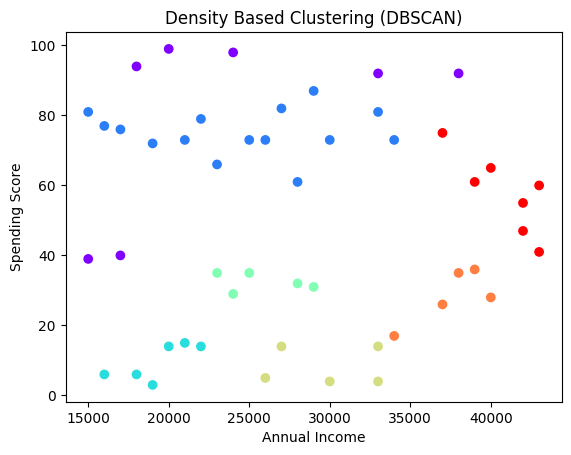

In [3]:
# ---------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------
# 2. LOAD DATASET
# ---------------------------------------------------------

data = pd.read_csv("/content/sample_data/customer_density_dataset.csv")

print("Dataset Preview:")
print(data.head())


# ---------------------------------------------------------
# 3. SELECT FEATURES
# ---------------------------------------------------------

X = data[['Annual_Income','Spending_Score']]


# ---------------------------------------------------------
# 4. SCALE DATA (IMPORTANT FOR DBSCAN)
# ---------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ---------------------------------------------------------
# 5. APPLY DBSCAN CLUSTERING
# ---------------------------------------------------------

db = DBSCAN(eps=0.5, min_samples=5)

# eps means epsilon, which defines the maximum distance between two points to be considered neighbors.
'''
If distance between points ≤ 0.5 → they are neighbors
If distance > 0.5 → they are not neighbors
min_samples = 5 :  At least 5 nearby points are needed to create a cluster
'''

clusters = db.fit_predict(X_scaled)

data['Cluster'] = clusters

print("\nClustered Data:")
print(data.head())


# ---------------------------------------------------------
# 6. VISUALIZE CLUSTERS
# ---------------------------------------------------------

plt.scatter(data['Annual_Income'],
            data['Spending_Score'],
            c=data['Cluster'],
            cmap='rainbow')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Density Based Clustering (DBSCAN)")

plt.show()